# Audience-Aware Scientific Abstract Simplification
**CS6120 Final Project** — SciLay dataset, Llama 3 8B, Prompt Optimization + Self-Refinement

### Before you start
1. **Runtime → Change runtime type → T4 GPU** (free tier is fine)
2. Add a Colab secret: click the **key icon** in the left sidebar → `HF_TOKEN` = your Hugging Face read token
3. Accept the Llama 3 license at huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct

### Run order
| Step | Cell | GPU? | Skip if... |
|------|------|------|------------|
| 0 | Install | No | never |
| 1 | HF token | No | never |
| 2 | EDA | No | you have EDA stats |
| 3 | Metrics | No | never (needed by all steps) |
| 4 | Llama zero-shot | **Yes** | you have `llama3_zeroshot_results.json` |
| 5 | T5 baseline | **Yes** | you have `t5_results.json` |
| 6 | BART baseline | **Yes** | you have `bart_results.json` |
| 7 | Reload Llama | **Yes** | run before steps 8–9 |
| 8 | Prompt optimization | **Yes** | you have `promptsearch_results.json` |
| 9 | **Self-refinement** | **Yes** | this is the new step |
| 10 | Results table | No | after step 9 |
| 11 | Figures | No | after step 10 |
| 12 | Download | No | last |

**Only need self-refinement?** Run steps 0, 1, 3, 7, 8, 9, 10, 11, 12 (upload your saved JSON files first).


## Step 0 — Install dependencies

In [1]:
!pip install -q transformers accelerate bitsandbytes datasets evaluate rouge_score bert_score textstat sacrebleu sentencepiece matplotlib pandas numpy huggingface_hub


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.9 MB/s eta 0:00:00


## Step 1 — Hugging Face token (Colab Secrets)
Add secret `HF_TOKEN` in the sidebar, then run:

In [2]:
import os
from google.colab import userdata
from huggingface_hub import login
"HF"
os.environ["nlp"] = userdata.get("nlp")
login(token=os.environ["nlp"], add_to_git_credential=False)
print("Logged in to Hugging Face.")


Logged in to Hugging Face.


## Step 2 — Load SciLay + Exploratory Data Analysis (CPU, ~3 min)

In [3]:
#!/usr/bin/env python3
# STEP 2: Load SciLay + Run EDA
# No GPU needed — runs on free Colab CPU
# Dataset: disi-unibo-nlp/SciLay
# Keys: technical_text (abstract), plain_text (lay summary), journal

import pandas as pd
import numpy as np
import textstat
import json
from datasets import load_dataset

# ── Load Dataset ──────────────────────────────────────────────────────────────
print("Loading SciLay (all journals)...")
dataset = load_dataset("disi-unibo-nlp/SciLay", "all")
print(f"Train: {len(dataset['train'])} | Val: {len(dataset['validation'])} | Test: {len(dataset['test'])}")

# Confirm field names
sample = dataset['train'][0]
print("\nFields available:", list(sample.keys()))
print("\nSample technical_text (abstract, first 300 chars):")
print(sample['technical_text'][:300])
print("\nSample plain_text (lay summary, first 300 chars):")
print(sample['plain_text'][:300])
print("\nJournal:", sample['journal'])

# ── Journal → Domain Mapping ─────────────────────────────────────────────────
# SciLay subset codes and their domains
JOURNAL_DOMAIN = {
    'NC':    'biology',      # Nature Communications
    'A':     'biology',      # Animals (MDPI)
    'PLGEN': 'biology',      # PLoS Genetics
    'PLPAT': 'medicine',     # PLoS Pathogens
    'PLCB':  'cs',           # PLoS Computational Biology
    'PLNTD': 'medicine',     # PLoS Neglected Tropical Diseases
    'B':     'biology',      # Biology
    'I':     'biology',      # Insects
    'PLB':   'biology',      # PLoS Biology
    'CB':    'biology',      # Communications Biology
    'SD':    'cs',           # Scientific Data
    'MBIO':  'medicine',     # mBio
    'C':     'medicine',     # Cancers
    'OTHER': 'other',
}

def get_domain(journal_str):
    """Map journal name string to domain using keyword matching."""
    j = journal_str.lower()
    if any(x in j for x in ['cancer', 'pathogen', 'neglected', 'mbio', 'disease']):
        return 'medicine'
    elif any(x in j for x in ['computational', 'scientific data']):
        return 'cs'
    elif any(x in j for x in ['genetics', 'biology', 'nature', 'animal',
                                'insect', 'communications bio']):
        return 'biology'
    else:
        return 'other'

# ── Rare word proxy ───────────────────────────────────────────────────────────
def rare_word_ratio(text):
    words = text.lower().split()
    if not words:
        return 0.0
    return sum(1 for w in words if len(w) > 8) / len(words)

# ── Compute Stats ─────────────────────────────────────────────────────────────
print("\nComputing FKGL and statistics (2-3 minutes)...")

records = []
for split in ['train', 'validation', 'test']:
    for example in dataset[split]:
        abstract = example['technical_text']
        summary  = example['plain_text']
        journal  = example.get('journal', '')

        # Filter very short examples
        if not abstract or not summary:
            continue
        if len(summary.split()) < 30 or len(abstract.split()) < 30:
            continue

        src_fkgl   = textstat.flesch_kincaid_grade(abstract)
        ref_fkgl   = textstat.flesch_kincaid_grade(summary)
        src_tokens = len(abstract.split())
        ref_tokens = len(summary.split())
        src_rare   = rare_word_ratio(abstract)
        ref_rare   = rare_word_ratio(summary)
        domain     = get_domain(journal)

        records.append({
            'split':      split,
            'journal':    journal,
            'domain':     domain,
            'src_fkgl':   src_fkgl,
            'ref_fkgl':   ref_fkgl,
            'fkgl_delta': src_fkgl - ref_fkgl,
            'src_tokens': src_tokens,
            'ref_tokens': ref_tokens,
            'len_ratio':  ref_tokens / max(src_tokens, 1),
            'src_rare':   src_rare,
            'ref_rare':   ref_rare,
        })

df = pd.DataFrame(records)
print(f"Total valid examples: {len(df)}")

# ── Print Summary ─────────────────────────────────────────────────────────────
print("\n=== OVERALL STATS ===")
print(df[['src_fkgl','ref_fkgl','fkgl_delta',
          'src_tokens','ref_tokens','src_rare','ref_rare']].describe().round(2))

print("\n=== FKGL BY DOMAIN ===")
print(df.groupby('domain')[['src_fkgl','ref_fkgl','fkgl_delta']].mean().round(2))

print("\n=== TOKEN LENGTH BY DOMAIN ===")
print(df.groupby('domain')[['src_tokens','ref_tokens','len_ratio']].mean().round(2))

print("\n=== DOMAIN DISTRIBUTION ===")
print(df['domain'].value_counts())

print("\n=== TOP JOURNALS ===")
print(df['journal'].value_counts().head(10))

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv('eda_results.csv', index=False)

stats = {
    'overall': {
        'mean_src_fkgl':   round(float(df['src_fkgl'].mean()), 2),
        'mean_ref_fkgl':   round(float(df['ref_fkgl'].mean()), 2),
        'mean_fkgl_delta': round(float(df['fkgl_delta'].mean()), 2),
        'mean_src_tokens': round(float(df['src_tokens'].mean()), 1),
        'mean_ref_tokens': round(float(df['ref_tokens'].mean()), 1),
        'mean_src_rare':   round(float(df['src_rare'].mean()), 3),
        'mean_ref_rare':   round(float(df['ref_rare'].mean()), 3),
    },
    'by_domain': df.groupby('domain')[['src_fkgl','ref_fkgl','fkgl_delta']].mean().round(2).to_dict()
}

with open('eda_summary.json', 'w') as f:
    json.dump(stats, f, indent=2)

print("\n=== COPY THESE INTO YOUR PAPER ===")
print(json.dumps(stats['overall'], indent=2))
print("\nSaved: eda_results.csv + eda_summary.json")

Loading SciLay (all journals)...


README.md:   0%|          | 0.00/18.3k [00:00<?, ?B/s]

all/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  195MB            

all/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

all/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  238MB            

...

all/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/35026 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4380 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4384 [00:00<?, ? examples/s]

Train: 35026 | Val: 4380 | Test: 4384

Fields available: ['doi', 'pmcid', 'plain_text', 'technical_text', 'full_text', 'journal', 'topics', 'keywords']

Sample technical_text (abstract, first 300 chars):
Single-cell RNA sequencing (scRNA-seq) is a versatile tool for discovering and annotating cell types and states, but the determination and annotation of cell subtypes is often subjective and arbitrary. Often, it is not even clear whether a given cluster is uniform. Here we present an entropy-based s

Sample plain_text (lay summary, first 300 chars):
Single cell RNA-seq is a powerful method to assign cell identity, but the purity of cell clusters arising from this data is not clear. Here the authors present an entropy-based statistic called ROGUE to quantify the purity of cell clusters, and identify subtypes within clusters.

Journal: nature communications

Computing FKGL and statistics (2-3 minutes)...
Total valid examples: 43060

=== OVERALL STATS ===
       src_fkgl  ref_fkgl  fkgl_d

## Step 3 — Evaluation metrics (SARI, ROUGE, BLEU, BERTScore, FKGL, NLI FactScore)

In [4]:
!pip install -q sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 14.3 MB/s eta 0:00:00


In [5]:
import json
import numpy as np
import textstat
import torch
from bert_score import score as bert_score_fn
from evaluate import load
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Metrics via HuggingFace evaluate
rouge_metric = load("rouge")
bleu_metric  = load("bleu")
sari_metric  = load("sari")

# Factual consistency via NLI entailment (replaces AlignScore, installs cleanly)
print("Loading NLI model for factual consistency...")
NLI_MODEL = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
nli_tok   = AutoTokenizer.from_pretrained(NLI_MODEL)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL)
nli_model.eval()
if torch.cuda.is_available():
    nli_model = nli_model.cuda()
print("Ready.")


def factual_consistency(sources, predictions):
    """
    Returns mean entailment probability: does the source entail the prediction?
    High score = prediction is supported by source = factually consistent.
    """
    scores = []
    for src, pred in zip(sources, predictions):
        inputs = nli_tok(src, pred, truncation=True, max_length=512,
                         return_tensors="pt")
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            logits = nli_model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0]
        # label order: 0=entailment, 1=neutral, 2=contradiction
        scores.append(float(probs[0].item()))
    return float(np.mean(scores))


def evaluate_system(sources, predictions, references, system_name="model"):
    """
    sources:     original abstracts     (technical_text)
    predictions: model simplifications
    references:  human lay summaries    (plain_text)
    """
    print(f"\nEvaluating: {system_name} ({len(sources)} examples)")
    assert len(sources) == len(predictions) == len(references)

    # 1. SARI
    sari = sari_metric.compute(
        sources=sources,
        predictions=predictions,
        references=[[r] for r in references]
    )['sari']

    # 2. ROUGE-L
    rougeL = rouge_metric.compute(
        predictions=predictions,
        references=references,
        rouge_types=['rougeL']
    )['rougeL']

    # 3. BLEU-4
    bleu4 = bleu_metric.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )['bleu']

    # 4. BERTScore F1
    _, _, F1 = bert_score_fn(predictions, references, lang='en', verbose=False)
    bertscore = float(F1.mean().item())

    # 5. FKGL reduction
    src_fkgl  = [textstat.flesch_kincaid_grade(s) for s in sources]
    pred_fkgl = [textstat.flesch_kincaid_grade(p) for p in predictions]
    fkgl_delta = float(np.mean([s - p for s, p in zip(src_fkgl, pred_fkgl)]))

    # 6. Factual consistency (NLI entailment)
    factscore = factual_consistency(sources, predictions)

    results = {
        'system':     system_name,
        'n':          len(sources),
        'SARI':       round(sari, 3),
        'ROUGE-L':    round(rougeL, 3),
        'BLEU-4':     round(bleu4, 3),
        'BERTScore':  round(bertscore, 3),
        'FKGL_delta': round(fkgl_delta, 2),
        'FactScore':  round(factscore, 3),
    }
    print(json.dumps(results, indent=2))
    return results


# ── Sanity Check ──
if __name__ == "__main__":
    sources = [
        "The mitochondrial permeability transition pore (mPTP) is a nonselective "
        "channel implicated in apoptotic and necrotic cell death pathways.",
        "Receptor tyrosine kinases (RTKs) are high-affinity cell surface receptors "
        "for many polypeptide growth factors, cytokines, and hormones.",
    ]
    predictions = [
        "Cells have tiny doors that can open and cause the cell to die.",
        "Some proteins on the surface of cells receive signals that help cells grow.",
    ]
    references = [
        "Special channels in cells can open and lead to cell death.",
        "Certain proteins on cells receive growth signals.",
    ]
    evaluate_system(sources, predictions, references, "sanity_check")
    print("\nSanity check passed!")

Loading NLI model for factual consistency...


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "sanity_check",
  "n": 2,
  "SARI": 64.458,
  "ROUGE-L": 0.458,
  "BLEU-4": 0.0,
  "BERTScore": 0.947,
  "FKGL_delta": 12.47,
  "FactScore": 0.72
}

Sanity check passed!


## Step 4 — Llama 3 8B zero-shot (3 audiences, 50 test examples, ~30–45 min)

In [6]:
import torch
import json
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# reduce memory fragmentation on T4
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading Llama 3 8B Instruct (4-bit)...")
# Retrieve the token from the environment variable
hf_token = os.environ.get("nlp")

# Ensure the token is available and pass it to from_pretrained
if hf_token is None:
    raise ValueError("HF_TOKEN environment variable is not set. Please set it to your Hugging Face access token.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token
)
model.eval()
print("Model loaded.")

AUDIENCE_PROMPTS = {
    "general": (
        "You are a science communicator. Rewrite the following scientific abstract "
        "in plain English for a general adult reader with no scientific background. "
        "Keep all the key findings but use simple, everyday language.\n\n"
        "Abstract:\n{abstract}\n\nSimplified version:"
    ),
    "middle_school": (
        "You are a science teacher. Rewrite the following scientific abstract "
        "so that a middle school student aged 12 to 14 can understand it. "
        "Use very simple words and short sentences. Explain any technical terms.\n\n"
        "Abstract:\n{abstract}\n\nSimplified version:"
    ),
    "undergraduate": (
        "You are a science writer. Rewrite the following scientific abstract "
        "for an undergraduate student with basic science knowledge but no "
        "specialization in this field. Keep technical accuracy but clarify "
        "any highly specialized terminology.\n\n"
        "Abstract:\n{abstract}\n\nSimplified version:"
    ),
}

def generate(abstract, audience="general", max_new_tokens=256):
    prompt   = AUDIENCE_PROMPTS[audience].format(abstract=abstract)
    messages = [{"role": "user", "content": prompt}]

    # tokenize returns a plain tensor (not a dict)
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=False,          # <-- force plain tensor
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = output[0][input_ids.shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

print("\nLoading SciLay...")
dataset = load_dataset("disi-unibo-nlp/SciLay", "all")

N = 50   # START SMALL — change to 200 once you confirm it works
test_data = dataset['test'].select(range(min(N, len(dataset['test']))))
sources    = [ex['technical_text'] for ex in test_data]
references = [ex['plain_text']     for ex in test_data]
journals   = [ex.get('journal', '') for ex in test_data]
print(f"Running on {len(sources)} test examples")

all_results = {}
for audience in ["general", "middle_school", "undergraduate"]:
    print(f"\n{'='*50}\nAudience: {audience}\n{'='*50}")
    predictions = []
    for i, abstract in enumerate(sources):
        if i % 10 == 0:
            print(f"  {i}/{len(sources)}")
        predictions.append(generate(abstract, audience=audience))

    pd.DataFrame({
        'source': sources, 'prediction': predictions,
        'reference': references, 'journal': journals,
    }).to_csv(f'llama3_zeroshot_{audience}_predictions.csv', index=False)

    results = evaluate_system(
        sources=sources, predictions=predictions,
        references=references, system_name=f"llama3_zeroshot_{audience}"
    )
    all_results[audience] = results

with open('llama3_zeroshot_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("\nDone! Saved llama3_zeroshot_results.json")

Loading Llama 3 8B Instruct (4-bit)...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging


Evaluating: llama3_zeroshot_undergraduate (50 examples)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "llama3_zeroshot_undergraduate",
  "n": 50,
  "SARI": 36.609,
  "ROUGE-L": 0.12,
  "BLEU-4": 0.016,
  "BERTScore": 0.853,
  "FKGL_delta": 3.37,
  "FactScore": 0.616
}

Done! Saved llama3_zeroshot_results.json


**bold text**## Step 5 — T5 baseline (fine-tune + evaluate, ~20 min)
`MODEL_KEY` is already set to `"t5"`.

In [7]:
import torch
import json
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)

# ─────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────
SEED = 42
set_seed(SEED)

# ─────────────────────────────────────────────
# Ensure the metrics cell was executed
# ─────────────────────────────────────────────
if "evaluate_system" not in globals():
    raise RuntimeError(
        "evaluate_system is not defined. "
        "Run the Step 3 metrics/evaluation cell before running T5."
    )

# ─────────────────────────────────────────────
# T5 configuration
# ─────────────────────────────────────────────
MODEL_KEY = "t5"

cfg = {
    "model_name": "t5-base",
    "max_input": 512,
    "max_target": 200,
    "learning_rate": 3e-4,
    "batch_size": 8,
    "epochs": 3,
    "prefix": "summarize: ",
}

print(f"Training model: {cfg['model_name']}")

# ─────────────────────────────────────────────
# Load SciLay
# ─────────────────────────────────────────────
dataset = load_dataset("disi-unibo-nlp/SciLay", "all")

print(
    f"Train: {len(dataset['train'])} | "
    f"Validation: {len(dataset['validation'])} | "
    f"Test: {len(dataset['test'])}"
)

# Development subset for faster training on a T4.
# Remove or comment out these two lines for full-dataset training.
dataset["train"] = dataset["train"].select(
    range(min(5000, len(dataset["train"])))
)
dataset["validation"] = dataset["validation"].select(
    range(min(500, len(dataset["validation"])))
)

# ─────────────────────────────────────────────
# Tokenizer and model
# ─────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
model = AutoModelForSeq2SeqLM.from_pretrained(cfg["model_name"])


def preprocess(examples):
    inputs = [
        cfg["prefix"] + text
        for text in examples["technical_text"]
    ]
    targets = examples["plain_text"]

    model_inputs = tokenizer(
        inputs,
        max_length=cfg["max_input"],
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=cfg["max_target"],
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


print("Tokenizing dataset...")

tokenized = dataset.map(
    preprocess,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

# ─────────────────────────────────────────────
# Training arguments
# ─────────────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5_scilay",
    num_train_epochs=cfg["epochs"],
    per_device_train_batch_size=cfg["batch_size"],
    per_device_eval_batch_size=cfg["batch_size"],
    learning_rate=cfg["learning_rate"],
    warmup_steps=300,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=cfg["max_target"],
    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    report_to="none",
    save_total_limit=1,
    seed=SEED,
    data_seed=SEED,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

# ─────────────────────────────────────────────
# Train
# ─────────────────────────────────────────────
print("Training T5...")
trainer.train()
print("T5 training complete.")

# ─────────────────────────────────────────────
# Generate test predictions
# ─────────────────────────────────────────────
N = 50  # Increase later, but use the same N for every system.

test_data = dataset["test"].select(
    range(min(N, len(dataset["test"])))
)

sources = [
    example["technical_text"]
    for example in test_data
]

references = [
    example["plain_text"]
    for example in test_data
]

journals = [
    example.get("journal", "")
    for example in test_data
]

predictions = []

model.eval()

for index, abstract in enumerate(sources, start=1):
    inputs = tokenizer(
        cfg["prefix"] + abstract,
        return_tensors="pt",
        max_length=cfg["max_input"],
        truncation=True,
    ).to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=cfg["max_target"],
            num_beams=4,
            early_stopping=True,
        )

    prediction = tokenizer.decode(
        generated[0],
        skip_special_tokens=True,
    )

    predictions.append(prediction)

    if index % 10 == 0:
        print(f"Generated {index}/{len(sources)} T5 outputs")

# ─────────────────────────────────────────────
# Save predictions
# ─────────────────────────────────────────────
t5_predictions_df = pd.DataFrame(
    {
        "source": sources,
        "prediction": predictions,
        "reference": references,
        "journal": journals,
    }
)

t5_predictions_df.to_csv(
    "t5_predictions.csv",
    index=False,
)

# ─────────────────────────────────────────────
# Evaluate and save metrics
# ─────────────────────────────────────────────
results = evaluate_system(
    sources,
    predictions,
    references,
    system_name="t5_finetuned",
)

with open("t5_results.json", "w") as file:
    json.dump(results, file, indent=2)

print("\nSaved:")
print("- t5_predictions.csv")
print("- t5_results.json")

Training model: t5-base
Train: 35026 | Validation: 4380 | Test: 4384


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

...

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


T5 training complete.
Generated 10/50 T5 outputs
Generated 20/50 T5 outputs
Generated 30/50 T5 outputs
Generated 40/50 T5 outputs
Generated 50/50 T5 outputs

Evaluating: t5_finetuned (50 examples)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "t5_finetuned",
  "n": 50,
  "SARI": 44.223,
  "ROUGE-L": 0.343,
  "BLEU-4": 0.193,
  "BERTScore": 0.898,
  "FKGL_delta": 0.98,
  "FactScore": 0.974
}

Saved:
- t5_predictions.csv
- t5_results.json


## Step 6 — BART baseline (fine-tune + evaluate, ~20 min)
`MODEL_KEY` is set to `"bart"`.

In [8]:
import gc
import torch
import json
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)

# ─────────────────────────────────────────────
# Clear T5 objects from memory before loading BART
# ─────────────────────────────────────────────
variables_to_clear = [
    "trainer",
    "model",
    "tokenizer",
    "tokenized",
    "data_collator",
]

for variable_name in variables_to_clear:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ─────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────
SEED = 42
set_seed(SEED)

# ─────────────────────────────────────────────
# Ensure the metrics cell was executed
# ─────────────────────────────────────────────
if "evaluate_system" not in globals():
    raise RuntimeError(
        "evaluate_system is not defined. "
        "Run the Step 3 metrics/evaluation cell before running BART."
    )

# ─────────────────────────────────────────────
# BART configuration
# ─────────────────────────────────────────────
MODEL_KEY = "bart"

cfg = {
    "model_name": "facebook/bart-base",
    "max_input": 512,
    "max_target": 200,
    "learning_rate": 3e-5,
    "batch_size": 4,
    "epochs": 3,
    "prefix": "",
}

print(f"Training model: {cfg['model_name']}")

# ─────────────────────────────────────────────
# Load SciLay
# ─────────────────────────────────────────────
dataset = load_dataset("disi-unibo-nlp/SciLay", "all")

print(
    f"Train: {len(dataset['train'])} | "
    f"Validation: {len(dataset['validation'])} | "
    f"Test: {len(dataset['test'])}"
)

# Development subset for faster training on a T4.
# Remove or comment out these two lines for full-dataset training.
dataset["train"] = dataset["train"].select(
    range(min(5000, len(dataset["train"])))
)
dataset["validation"] = dataset["validation"].select(
    range(min(500, len(dataset["validation"])))
)

# ─────────────────────────────────────────────
# Tokenizer and model
# ─────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
model = AutoModelForSeq2SeqLM.from_pretrained(cfg["model_name"])


def preprocess(examples):
    inputs = [
        cfg["prefix"] + text
        for text in examples["technical_text"]
    ]
    targets = examples["plain_text"]

    model_inputs = tokenizer(
        inputs,
        max_length=cfg["max_input"],
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=cfg["max_target"],
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


print("Tokenizing dataset...")

tokenized = dataset.map(
    preprocess,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

# ─────────────────────────────────────────────
# Training arguments
# ─────────────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir="./bart_scilay",
    num_train_epochs=cfg["epochs"],
    per_device_train_batch_size=cfg["batch_size"],
    per_device_eval_batch_size=cfg["batch_size"],
    learning_rate=cfg["learning_rate"],
    warmup_steps=300,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=cfg["max_target"],
    gradient_checkpointing=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    report_to="none",
    save_total_limit=1,
    seed=SEED,
    data_seed=SEED,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

# ─────────────────────────────────────────────
# Train
# ─────────────────────────────────────────────
print("Training BART...")
trainer.train()
print("BART training complete.")

# ─────────────────────────────────────────────
# Generate test predictions
# ─────────────────────────────────────────────
N = 50  # Must match T5 and your other systems.

test_data = dataset["test"].select(
    range(min(N, len(dataset["test"])))
)

sources = [
    example["technical_text"]
    for example in test_data
]

references = [
    example["plain_text"]
    for example in test_data
]

journals = [
    example.get("journal", "")
    for example in test_data
]

predictions = []

model.eval()

for index, abstract in enumerate(sources, start=1):
    inputs = tokenizer(
        cfg["prefix"] + abstract,
        return_tensors="pt",
        max_length=cfg["max_input"],
        truncation=True,
    ).to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=cfg["max_target"],
            num_beams=4,
            early_stopping=True,
        )

    prediction = tokenizer.decode(
        generated[0],
        skip_special_tokens=True,
    )

    predictions.append(prediction)

    if index % 10 == 0:
        print(f"Generated {index}/{len(sources)} BART outputs")

# ─────────────────────────────────────────────
# Save predictions
# ─────────────────────────────────────────────
bart_predictions_df = pd.DataFrame(
    {
        "source": sources,
        "prediction": predictions,
        "reference": references,
        "journal": journals,
    }
)

bart_predictions_df.to_csv(
    "bart_predictions.csv",
    index=False,
)

# ─────────────────────────────────────────────
# Evaluate and save metrics
# ─────────────────────────────────────────────
results = evaluate_system(
    sources,
    predictions,
    references,
    system_name="bart_finetuned",
)

with open("bart_results.json", "w") as file:
    json.dump(results, file, indent=2)

print("\nSaved:")
print("- bart_predictions.csv")
print("- bart_results.json")

Training model: facebook/bart-base
Train: 35026 | Validation: 4380 | Test: 4384


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


BART training complete.
Generated 10/50 BART outputs
Generated 20/50 BART outputs
Generated 30/50 BART outputs
Generated 40/50 BART outputs
Generated 50/50 BART outputs

Evaluating: bart_finetuned (50 examples)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "bart_finetuned",
  "n": 50,
  "SARI": 43.828,
  "ROUGE-L": 0.324,
  "BLEU-4": 0.178,
  "BERTScore": 0.895,
  "FKGL_delta": 0.7,
  "FactScore": 0.868
}

Saved:
- bart_predictions.csv
- bart_results.json


## Step 7 — Reload Llama 3 for prompt search + self-refinement

In [9]:
import torch, os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"
hf_token = os.environ.get("HF_TOKEN")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
print("Reloading Llama 3...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", token=hf_token)
model.eval()

def generate(prompt, max_new_tokens=256):
    messages = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=False).to(model.device)
    with torch.no_grad():
        out = model.generate(input_ids, max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][input_ids.shape[-1]:], skip_special_tokens=True).strip()

print("Ready.")


Reloading Llama 3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Ready.


## Step 8 — Stage 1: Automatic prompt optimization (~45 min)

In [10]:
import json
import numpy as np
import pandas as pd
from datasets import load_dataset
from evaluate import load as load_metric

sari_metric = load_metric("sari")

# ── Pool of candidate prompts to search over (per audience) ──
CANDIDATE_PROMPTS = {
    "general": [
        "Rewrite this scientific abstract in plain English for a general reader. Keep all key findings:\n\n{abstract}\n\nPlain version:",
        "Explain the following abstract to someone with no science background, using simple everyday words while keeping the facts accurate:\n\n{abstract}\n\nExplanation:",
        "You are a science journalist. Summarize this abstract for a newspaper's general audience, keeping it accurate but easy to read:\n\n{abstract}\n\nSummary:",
        "Simplify this scientific text so any adult can understand it. Do not add information that is not in the original:\n\n{abstract}\n\nSimplified:",
    ],
    "middle_school": [
        "Rewrite this abstract so a 12-year-old can understand it. Use short sentences and simple words, but keep the facts correct:\n\n{abstract}\n\nSimple version:",
        "You are a science teacher explaining this to a middle school class. Keep it accurate and easy:\n\n{abstract}\n\nExplanation:",
        "Explain this research to a curious middle schooler. Define hard words. Do not make up facts:\n\n{abstract}\n\nExplanation:",
        "Turn this abstract into a simple explanation for a school student aged 12-14, staying faithful to the original findings:\n\n{abstract}\n\nSimple explanation:",
    ],
    "undergraduate": [
        "Rewrite this abstract for an undergraduate who has taken intro science courses. Clarify jargon but keep technical accuracy:\n\n{abstract}\n\nClarified version:",
        "Explain this abstract to a first-year college student, keeping the important technical points but making it clearer:\n\n{abstract}\n\nExplanation:",
        "You are a teaching assistant. Rewrite this for undergraduates, preserving accuracy while improving readability:\n\n{abstract}\n\nRewrite:",
        "Make this abstract accessible to an undergraduate science student without oversimplifying the findings:\n\n{abstract}\n\nAccessible version:",
    ],
}

# ── Load data ──
dataset = load_dataset("disi-unibo-nlp/SciLay", "all")
val_data  = dataset['validation'].select(range(15))   # small val set for search
test_data = dataset['test'].select(range(50))         # same 50 as baseline

val_src  = [ex['technical_text'] for ex in val_data]
val_ref  = [ex['plain_text']     for ex in val_data]
test_src = [ex['technical_text'] for ex in test_data]
test_ref = [ex['plain_text']     for ex in test_data]
test_jrn = [ex.get('journal','') for ex in test_data]

# ── Search: find best prompt per audience on validation set ──
best_prompts = {}
for audience, candidates in CANDIDATE_PROMPTS.items():
    print(f"\n=== Searching prompts for: {audience} ===")
    best_sari, best_p = -1, None
    for idx, template in enumerate(candidates):
        preds = [generate(template.format(abstract=a)) for a in val_src]
        sari = sari_metric.compute(sources=val_src, predictions=preds,
                                   references=[[r] for r in val_ref])['sari']
        print(f"  candidate {idx+1}: SARI={sari:.2f}")
        if sari > best_sari:
            best_sari, best_p = sari, template
    best_prompts[audience] = best_p
    print(f"  BEST for {audience}: SARI={best_sari:.2f}")

# Save which prompts won
with open('best_prompts.json', 'w') as f:
    json.dump(best_prompts, f, indent=2)

# ── Evaluate best prompts on the test set ──
all_results = {}
for audience, template in best_prompts.items():
    print(f"\n=== Testing optimized prompt: {audience} ===")
    preds = []
    for i, a in enumerate(test_src):
        if i % 10 == 0: print(f"  {i}/{len(test_src)}")
        preds.append(generate(template.format(abstract=a)))

    pd.DataFrame({'source': test_src, 'prediction': preds,
                  'reference': test_ref, 'journal': test_jrn
                 }).to_csv(f'promptsearch_{audience}_predictions.csv', index=False)

    results = evaluate_system(test_src, preds, test_ref,
                              system_name=f"promptsearch_{audience}")
    all_results[audience] = results

with open('promptsearch_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("\nDone! Saved promptsearch_results.json + best_prompts.json")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== Searching prompts for: general ===


[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

  candidate 1: SARI=36.66


[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

...

[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging


Evaluating: promptsearch_undergraduate (50 examples)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "promptsearch_undergraduate",
  "n": 50,
  "SARI": 38.034,
  "ROUGE-L": 0.141,
  "BLEU-4": 0.028,
  "BERTScore": 0.861,
  "FKGL_delta": 2.69,
  "FactScore": 0.661
}

Done! Saved promptsearch_results.json + best_prompts.json


## Step 9 — Stage 2: Self-refinement (~2–4 hrs on free T4)

If Colab disconnects, change at the top of this cell:
```python
N = 20
AUDIENCES = ["general"]
```


[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Self-refine audience: general
  0/50


[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

  10/50


[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "selfrefine_undergraduate_iter3",
  "n": 50,
  "SARI": 37.854,
  "ROUGE-L": 0.145,
  "BLEU-4": 0.031,
  "BERTScore": 0.862,
  "FKGL_delta": 2.49,
  "FactScore": 0.585
}

Evaluating: selfrefine_undergraduate (50 examples)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "system": "selfrefine_undergraduate",
  "n": 50,
  "SARI": 37.854,
  "ROUGE-L": 0.145,
  "BLEU-4": 0.031,
  "BERTScore": 0.862,
  "FKGL_delta": 2.49,
  "FactScore": 0.585
}

Saved self_refine_results.json


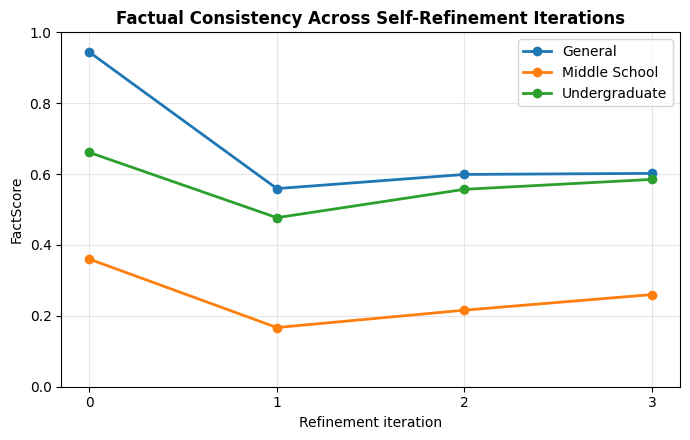

Saved figure3_selfrefine.pdf/png


In [11]:
# STEP: Stage 2 — Self-Refinement (Self-Refine style)
# Run AFTER prompt-search cell above. Free Colab T4 works (same 4-bit Llama setup).
# Tip: if session dies, rerun with N=20 or audience="general" only.

import json
import numpy as np
import pandas as pd
from datasets import load_dataset

AUDIENCE_DESCRIPTIONS = {
    "general": "a general adult reader with no scientific background",
    "middle_school": "a middle school student aged 12 to 14",
    "undergraduate": "an undergraduate student with basic science knowledge",
}

CRITIQUE_TEMPLATE = """You are a scientific fact-checker. Compare the SIMPLIFIED VERSION to the ORIGINAL ABSTRACT.

ORIGINAL ABSTRACT:
{source}

SIMPLIFIED VERSION:
{simplification}

List any scientific claims that were:
1. Dropped (important findings missing from the simplified version)
2. Altered (meaning changed or overstated)
3. Added (information not supported by the original)

Be specific and concise. If the simplified version is faithful, reply exactly: No issues found."""

REVISE_TEMPLATE = """Revise the simplified version for {audience_desc}. Fix the issues below while keeping the text accessible. Do not add claims that are not in the original abstract.

ORIGINAL ABSTRACT:
{source}

CURRENT SIMPLIFIED VERSION:
{simplification}

ISSUES TO FIX:
{critique}

Improved simplified version:"""

# Load best prompts from prompt-search step (or from file if re-running)
try:
    _ = best_prompts
except NameError:
    best_prompts = json.load(open("best_prompts.json"))

N = 50            # reduce to 20 if Colab disconnects
MAX_ITER = 3      # self-refinement rounds
AUDIENCES = ["general", "middle_school", "undergraduate"]  # or ["general"] for faster run

dataset = load_dataset("disi-unibo-nlp/SciLay", "all")
test_data = dataset["test"].select(range(min(N, len(dataset["test"]))))
test_src = [ex["technical_text"] for ex in test_data]
test_ref = [ex["plain_text"] for ex in test_data]
test_jrn = [ex.get("journal", "") for ex in test_data]

all_results = {}
iteration_summary = {}

for audience in AUDIENCES:
    print(f"\n{'='*60}\nSelf-refine audience: {audience}\n{'='*60}")
    template = best_prompts[audience]

    initial_preds, final_preds, per_example_iterations = [], [], []

    for i, source in enumerate(test_src):
        if i % 10 == 0:
            print(f"  {i}/{len(test_src)}")

        initial = generate(template.format(abstract=source))
        initial_preds.append(initial)

        current = initial
        iter_texts = [initial]
        iter_facts = []

        for step in range(1, MAX_ITER + 1):
            critique = generate(CRITIQUE_TEMPLATE.format(source=source, simplification=current))
            if "no issues found" in critique.lower():
                break

            revised = generate(REVISE_TEMPLATE.format(
                audience_desc=AUDIENCE_DESCRIPTIONS[audience],
                source=source,
                simplification=current,
                critique=critique,
            ))
            if not revised.strip():
                break

            fact = factual_consistency([source], [revised])
            if iter_facts and fact <= iter_facts[-1]:
                break

            current = revised
            iter_texts.append(current)
            iter_facts.append(fact)

        final_preds.append(current)
        per_example_iterations.append({"iter_texts": iter_texts})

    iteration_metrics = []
    for depth in range(MAX_ITER + 1):
        depth_preds = [ex["iter_texts"][min(depth, len(ex["iter_texts"]) - 1)] for ex in per_example_iterations]
        m = evaluate_system(test_src, depth_preds, test_ref, system_name=f"selfrefine_{audience}_iter{depth}")
        iteration_metrics.append({"iteration": depth, **{k: m[k] for k in ["SARI", "ROUGE-L", "BLEU-4", "BERTScore", "FKGL_delta", "FactScore"]}})

    iteration_summary[audience] = iteration_metrics

    pd.DataFrame({
        "source": test_src,
        "initial_prediction": initial_preds,
        "final_prediction": final_preds,
        "reference": test_ref,
        "journal": test_jrn,
    }).to_csv(f"selfrefine_{audience}_predictions.csv", index=False)

    results = evaluate_system(test_src, final_preds, test_ref, system_name=f"selfrefine_{audience}")
    all_results[audience] = results

output = {
    "by_audience": all_results,
    "iteration_metrics": iteration_summary,
    "config": {"n_test": N, "max_iterations": MAX_ITER},
}
with open("self_refine_results.json", "w") as f:
    json.dump(output, f, indent=2)
print("\nSaved self_refine_results.json")

# Figure 3
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
for audience, metrics in iteration_summary.items():
    xs = [m["iteration"] for m in metrics]
    ys = [m["FactScore"] for m in metrics]
    ax.plot(xs, ys, marker="o", linewidth=2, label=audience.replace("_", " ").title())
ax.set_xlabel("Refinement iteration")
ax.set_ylabel("FactScore")
ax.set_title("Factual Consistency Across Self-Refinement Iterations", fontweight="bold")
ax.set_xticks(range(MAX_ITER + 1))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure3_selfrefine.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figure3_selfrefine.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved figure3_selfrefine.pdf/png")


## Step 10 — Build final results table

In [12]:
import json
import pandas as pd

# ── Build final_results_table.csv from all saved result files ──
t5 = json.load(open('t5_results.json'))
bart = json.load(open('bart_results.json'))
llama_zeroshot = json.load(open('llama3_zeroshot_results.json'))
promptsearch = json.load(open('promptsearch_results.json'))

rows = [t5, bart] + list(llama_zeroshot.values()) + list(promptsearch.values())

# Add self-refinement rows if available
try:
    self_refine = json.load(open('self_refine_results.json'))
    general_sr = self_refine['by_audience']['general']
    general_sr['system'] = 'llama3_opt_selfrefine_general'
    rows.append(general_sr)
except FileNotFoundError:
    print("self_refine_results.json not found — run Stage 2 cell first")

results_df = pd.DataFrame(rows)
results_df.to_csv('final_results_table.csv', index=False)
print("Wrote final_results_table.csv")
print(results_df)

with open('audience_breakdown_results.json', 'w') as f:
    json.dump(llama_zeroshot, f, indent=2)
print("\nWrote audience_breakdown_results.json (zero-shot breakdown)")


Wrote final_results_table.csv
                          system   n    SARI  ROUGE-L  BLEU-4  BERTScore  \
0                   t5_finetuned  50  44.223    0.343   0.193      0.898   
1                 bart_finetuned  50  43.828    0.324   0.178      0.895   
2        llama3_zeroshot_general  50  36.582    0.112   0.012      0.848   
3  llama3_zeroshot_middle_school  50  36.491    0.092   0.005      0.832   
4  llama3_zeroshot_undergraduate  50  36.609    0.120   0.016      0.853   
5           promptsearch_general  50  36.383    0.144   0.014      0.862   
6     promptsearch_middle_school  50  38.083    0.093   0.007      0.828   
7     promptsearch_undergraduate  50  38.034    0.141   0.028      0.861   
8  llama3_opt_selfrefine_general  50  36.912    0.140   0.024      0.859   

   FKGL_delta  FactScore  
0        0.98      0.974  
1        0.70      0.868  
2        5.26      0.812  
3        7.88      0.416  
4        3.37      0.616  
5        4.33      0.944  
6        9.72      0

## Step 11 — Generate Figures 1, 2, and 3

In [13]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Serif'

results_df = pd.read_csv('final_results_table.csv')
aud = json.load(open('audience_breakdown_results.json'))
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

# ── Figure 1: SARI + FactScore across systems (grouped bar) ──
fig, ax = plt.subplots(figsize=(9,4.5))
systems = results_df['system'].tolist()
x = np.arange(len(systems)); w = 0.35
ax.bar(x - w/2, results_df['SARI'], w, label='SARI', color='#4C72B0')
ax2 = ax.twinx()
ax2.bar(x + w/2, results_df['FactScore'], w, label='FactScore', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(systems, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('SARI'); ax2.set_ylabel('FactScore')
ax.set_title('Simplification Quality vs. Factual Consistency', fontweight='bold')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figure1_systems.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure1_systems.png', bbox_inches='tight', dpi=300)
plt.close(); print("Saved Figure 1")

# ── Figure 2: THE TRADE-OFF — readability vs faithfulness by audience ──
order = ['undergraduate','general','middle_school']
labels = ['Undergraduate','General','Middle School']
fkgl = [aud[a]['FKGL_delta'] for a in order]
fact = [aud[a]['FactScore'] for a in order]

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(order)); w = 0.35
b1 = ax.bar(x - w/2, fkgl, w, label='Readability gain (Δ FKGL)', color='#55A868')
ax2 = ax.twinx()
b2 = ax2.bar(x + w/2, fact, w, label='Faithfulness (FactScore)', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Δ FKGL (higher = simpler)', color='#55A868')
ax2.set_ylabel('FactScore (higher = more faithful)', color='#C44E52')
ax2.set_ylim(0,1)
ax.set_title('The Readability–Faithfulness Trade-off Across Audiences', fontweight='bold')
for b,v in zip(b1,fkgl): ax.text(b.get_x()+b.get_width()/2, v+0.15, f'{v:.1f}', ha='center', fontsize=9)
for b,v in zip(b2,fact): ax2.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=9)
lines = [b1,b2]; ax.legend(lines,[l.get_label() for l in lines], loc='upper center')
plt.tight_layout()
plt.savefig('figure2_tradeoff.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure2_tradeoff.png', bbox_inches='tight', dpi=300)
plt.close(); print("Saved Figure 2 (your headline figure!)")

# Figure 3 from self-refinement
try:
    sr = json.load(open('self_refine_results.json'))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for audience, metrics in sr['iteration_metrics'].items():
        xs = [m['iteration'] for m in metrics]
        ys = [m['FactScore'] for m in metrics]
        ax.plot(xs, ys, marker='o', linewidth=2, label=audience.replace('_', ' ').title())
    ax.set_xlabel('Refinement iteration')
    ax.set_ylabel('FactScore')
    ax.set_title('Factual Consistency Across Self-Refinement Iterations', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure3_selfrefine.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure3_selfrefine.png', bbox_inches='tight', dpi=300)
    plt.close()
    print('Saved Figure 3')
except FileNotFoundError:
    print('Figure 3 skipped — run Step 9 first')

print("\nAll figures saved.")

Saved Figure 1
Saved Figure 2 (your headline figure!)
Saved Figure 3

All figures saved.


## Step 12 — Download all results

In [14]:
from google.colab import files

for f in [
    'figure1_systems.pdf', 'figure1_systems.png',
    'figure2_tradeoff.pdf', 'figure2_tradeoff.png',
    'figure3_selfrefine.pdf', 'figure3_selfrefine.png',
    'final_results_table.csv',
    'self_refine_results.json',
    'audience_breakdown_results.json',
    'llama3_zeroshot_results.json',
    'promptsearch_results.json',
    't5_results.json', 'bart_results.json',
]:
    try:
        files.download(f)
    except Exception as e:
        print(f"skip {f}: {e}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>